# import

In [1]:
import tensorflow as tf
assert tf.__version__.split('.')[0] == '2'
tf.__version__

'2.0.0-alpha0'

In [2]:
model_dir = '../data/models'

In [3]:
import collections, os, pickle, time

from matplotlib import pyplot as plt
import numpy as np
import numpy
import scipy.io.wavfile
import scipy.signal

%load_ext autoreload
%autoreload 2

In [4]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

import abase, audio, features, settings, signals as S, util

# make dataset

generation of efficient matrix-based training/eval sets

see below "use" section for streaming implementations

In [332]:
ab = abase.ABase()
ab.load('logmel')

loaded 54/54 (100.00%)


o_g_3


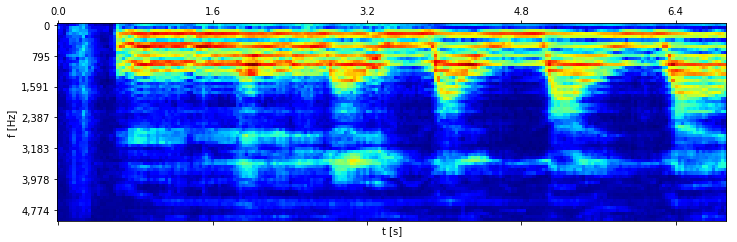

In [333]:
name = ab.sample()
print(name)
util.plot_logmel(ab.df.loc[name, 'logmel']);

In [146]:
ab_train = ab.query('rand_stable > 0.2')
ab_test = ab.query('rand_stable <= 0.2')
print('\n'.join([str(ab_train), str(ab_test)]))

ABase(n=39, series=18, what=o:12|t:12|ohoch:4|m:4|i:3|otief:2|var:2, who=p:12|g:12|a:8|m:4|k:3)
ABase(n=11, series=10, what=o:3|var:2|t:2|otief:1|m:1|w:1|i:1, who=g:7|a:3|k:1)


In [147]:
# => see "classes" below
ab.df.what.value_counts()

o        15
t        14
m         5
ohoch     4
var       4
i         4
otief     3
w         1
Name: what, dtype: int64

In [148]:
ab.df.w.value_counts()

o    22
t    14
m     5
v     4
i     4
w     1
Name: w, dtype: int64

In [233]:
def make_query(s):
    suffix = ''
    if s[-1] == '1':
        suffix = ' and ({})'.format(' or '.join([
            'inseries == "{}"'.format(i) for i in range(1, 6)
        ]))
        s = s[:-1]
    if s[-1] == '2':
        suffix = ' and inseries == "s2"'
        s = s[:-1]
    if '-' in s:
        q = ' or '.join(['what == "{}"'.format(_)
                         for _ in s.split('-') if _])
    else:
        q = ' or '.join(['w == "{}"'.format(_) for _ in s])
    return '({}){}'.format(q, suffix)

def split_df(df, classes):
    """One split vs.="_" the other."""
    a, b = classes.split('_')
    q1, q2 = make_query(a), make_query(b)
    return (
        df.query(q1),
        df.query(q2),
    )

a, b = split_df(ab_test.df, 'var-2_o1')
a.index, b.index

(Index(['var_g_s2', 'var_k_s2'], dtype='object', name='name'),
 Index(['o_a_2', 'o_g_1', 'o_g_3'], dtype='object', name='name'))

In [169]:
DataSet = collections.namedtuple('DataSet', ['x', 'y', 'idxs'])

def df_vs_df(df1, df2):
    """Returns df1 (y=0) vs. df2 (y=1)."""
    x0s = list(df1.logmel.values)
    x1s = list(df2.logmel.values)
    x0 = np.concatenate(x0s, axis=0) if x0s else []
    x1 = np.concatenate(x1s, axis=0) if x1s else []
    if len(x0) > 0 and len(x1) > 0:
        x = np.concatenate([x0, x1])
    else:
        x = x0 if x0 else x1
    y = np.concatenate([
        np.zeros(len(x0), dtype=np.int64),
        np.ones(len(x1), dtype=np.int64),
    ])
    idxs = [len(_) for _ in x0s] + [len(_) for _ in x1s]
    return DataSet(x, y, idxs)

def x_vs_y(df, x, y):
    return df_vs_df(df.query(x), df.query(y))

from PIL import Image

def pad(ds, pad_width):
    x_, y_, idxs_ = [], [], []
    i0 = 0
    for idx in ds.idxs:
        x_.append(np.pad(ds.x[i0:i0 + idx], ((pad_width, pad_width), (0, 0)), mode='constant'))
        y_.append(np.pad(ds.y[i0:i0 + idx], ((pad_width, pad_width),), mode='constant'))
        idxs_.append(idx + 2 * pad_width)
        i0 += idx
    return DataSet(np.concatenate(x_), np.concatenate(y_), idxs_)

def unpad(ds, pad_width):
    x_, y_, idxs_ = [], [], []
    i0 = pad_width
    for idx in ds.idxs:
        x_.append(ds.x[i0:i0 + idx - 2 * pad_width])
        y_.append(ds.y[i0:i0 + idx - 2 * pad_width])
        idxs_.append(idx - 2 * pad_width)
        i0 += idx
    return DataSet(np.concatenate(x_), np.concatenate(y_), idxs_)

def with_previous(ds, n, d=None):
    """Concatenates features with average from previous frames.

    Args:
      n: how many (preceeding) frames to consider
      d: dimension of the added vector (defaults to same dimensions as `x`)
    """
    padded = pad(ds, pad_width=n)
    w, h = padded.x.shape
    if d is None:
        d = h
    augmented = np.zeros((w, h + d))
    augmented[:, :h] = padded.x
    x = padded.x
    if d != h:
        x = np.array(Image.fromarray(x).resize((d, x.shape[0])))
    for i in range(n):
        augmented[:, h:] += np.roll(x, i, axis=0) / n
    return unpad(DataSet(augmented, padded.y, padded.idxs), pad_width=n)

((7074, 84),
 (7074,),
 [217, 217, 217, 217, 217, 217, 217, 217, 217, 217],
 0.631891433418151)

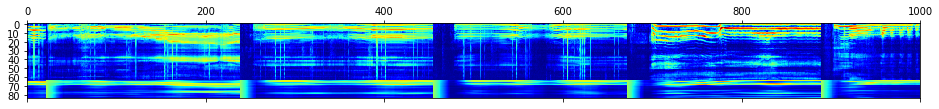

In [172]:
n, d = 20, 20
ds = df_vs_df(*split_df(ab_train.df, 't_o'))
ds = with_previous(ds, n=n, d=d)

plt.matshow(ds.x[2800:3800, :].T, cmap='jet')
ds.x.shape, ds.y.shape, ds.idxs[:10], ds.y.mean()

# train

## conf

In [57]:
class TfConf(object):
    def __init__(self, **kwargs):
        self.data = dict(**kwargs)
    def spawn(self, **kwargs):
        return TfConf(**{k:v for k, v in self.data.items()
                         if k not in kwargs}, **kwargs)
    def __setattr__(self, k, v):
        if k =='data':
            object.__setattr__(self, k, v)
            return
        assert k in self.data
        self.data[k] = v
    def __getattr__(self, k):
        return self.__getattribute__('data')[k]
    def __str__(self):
        return 'TfConf({})'.format(' '.join([
            '{}={}'.format(k, v)
            for k, v in sorted(self.data.items())
        ]))
    def __repr__(self):
        return str(self)
    def name(self, keys):
        return '-'.join(['{}={}'.format(k, v)
                         for k, v in self.data.items() if k in keys])

c = TfConf(a=1, b=2)
c.spawn(c=3, b=2.5)

conf_base = TfConf(
    features='logmel',
    # see split_df()
    classes='tm_o',
    # How to preprocess features : none, wp_{n}_{d}
    preprocessor='none',
    epochs=15,
    batch_size=10,
    optimizer='SGD',
    units=(),
    # tf.keras.model.fit(verbose)
    verbose=1,
    # name of the experiment
    experiment=None,
    # per experiment
    runs=3,
)

## train, experiment, classes

In [168]:
TrainEvalResults = collections.namedtuple('TrainEvalResults', ['conf', 'model', 'history', 'metrics'])

def make_ds(conf, df):
    ds = df_vs_df(*split_df(df, conf.classes))
    if conf.preprocessor == 'none':
        pass
    elif conf.preprocessor[:3] == 'wp_':
        parts = conf.preprocessor.split('_')
        ds = with_previous(ds, n=int(parts[1]), d=int(parts[2]))
    else:
        raise ValueError('unknown preprocessor: "{}"'.formatr(conf.preprocessor))
    return ds

def make_xy_tensors(conf, df):
    ds = make_ds(conf, df)
    return (
        tf.convert_to_tensor(ds.x),
        tf.one_hot(ds.y, depth=2, dtype=tf.float32),
    )

def train_eval(conf):
    global ab_train, ab_test
    
    train_xy = make_xy_tensors(conf, ab_train.df)

    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[train_xy[0].shape[1]]),
    ] + [
        tf.keras.layers.Dense(units=units, activation='relu')
        for units in conf.units
    ] + [
        tf.keras.layers.Dense(units=2, activation='softmax'),
    ])

    if conf.optimizer == 'SGD':
        optimizer = tf.optimizers.SGD()
    else:
        raise ValueError('unknown optimizer: "{}"'.formatr(conf.optimizer))

    if conf.verbose:
        model.summary()
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(*train_xy, epochs=conf.epochs,
                        batch_size=conf.batch_size, verbose=conf.verbose)

    metrics = dict(zip(
        model.metrics_names,
        model.evaluate(*make_xy_tensors(conf, ab_test.df),
                       verbose=conf.verbose),
    ))

    return TrainEvalResults(conf=conf, model=model, history=history.history,
                            metrics=metrics)

In [72]:
def mean_std(results, metric):
    values = np.array([result.metrics[metric] for result in results])
    return values.mean(), values.std()

def experiments(confs, keys):
    results = []
    for i, conf in enumerate(confs):
        name = '-'.join([str(conf.data[k]) for k in keys])
        print('#%03d %20s' % (i, name), end=': ')
        results.append([])
        for j in range(conf.runs):
            t0 = time.time()
            result = train_eval(conf)
            result.metrics['dt'] = time.time() - t0
            results[-1].append(result)
            print('%.4f' % result.metrics['accuracy'], end=', ')
        print(' -> %.4f ± %.4f' % mean_std(results[-1], 'accuracy'), end=' ')
        print(' [%.1fs ± %.1fs]' % mean_std(results[-1], 'dt'))
    return results

### test

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_4 (Flatten)          (None, 64)                0         
_________________________________________________________________
dense_4 (Dense)              (None, 2)                 130       
Total params: 130
Trainable params: 130
Non-trainable params: 0
_________________________________________________________________
Epoch 1/2
8875/8875 [==============================] - 1s 134us/sample - loss: 0.4855 - accuracy: 0.7886
Epoch 2/2
1924/1924 [==============================] - 0s 56us/sample - loss: 0.4107 - accuracy: 0.8280


{'loss': 0.41071110060767674, 'accuracy': 0.8279626}

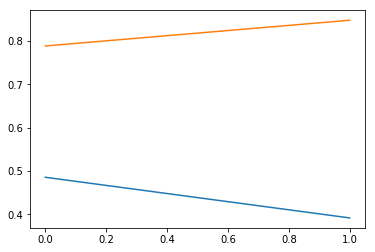

In [73]:
ter = train_eval(conf_base.spawn(epochs=2, classes='tmi_os'))
plt.plot(ter.history['loss'])
plt.plot(ter.history['accuracy'])
ter.metrics

## experiments

In [112]:
def save(name, result):
    """Stores {name}.h5 & {name}_*.json in `model_dir`."""
    result.model.save(os.path.join(model_dir, '{}.h5'.format(name)))
    for what, d in (('conf', result.conf.data), ('metrics', result.metrics),
                    ('history', result.history)):
        with open(os.path.join(model_dir, '{}_{}.json'.format(name, what)), 'w') as f:
            json.dump(util.pythonize(d), f, indent=2)

def plot_df(result, df, conf_update={}):
    """Plots pos/neg traces from `df`."""
    plt.figure(figsize=(15, 2))
    i0 = 0
    cols = {1.: 'r', 0.: 'g'}
    ds = make_ds(result.conf.spawn(**conf_update), df)
    for idx in ds.idxs:
        x = ds.x[i0:i0+idx]
        y = ds.y[i0:i0+idx]
        assert y.min() == y.max()
        y_ = result.model.predict(x)
        plt.plot(y_[:, 1], cols[y.min()])
        i0 += idx

### session 2

using all data, incl. new martha/kayle + hoch/otief

In [243]:
# the problem with o2 is that there is only a single "o" in the evalset ...
conf = conf_base.spawn(experiment='preprocessor2', verbose=0, epochs=2)
results1 = experiments([
    conf.spawn(classes=classes, preprocessor=preprocessor)
    for classes in ('tmi_o', 'tmi_o2')
    for preprocessor in ('none', 'wp_20_20', 'wp_10_10', 'wp_50_20', 'wp_20_50')
], ('classes', 'preprocessor',))

#000           tmi_o-none: 0.8664, 0.8747, 0.8706,  -> 0.8706 ± 0.0034  [2.8s ± 0.2s]
#001       tmi_o-wp_20_20: 0.8997, 0.8945, 0.8919,  -> 0.8954 ± 0.0032  [2.8s ± 0.1s]
#002       tmi_o-wp_10_10: 0.8612, 0.8555, 0.8966,  -> 0.8711 ± 0.0182  [2.8s ± 0.1s]
#003       tmi_o-wp_50_20: 0.7952, 0.9059, 0.9194,  -> 0.8735 ± 0.0556  [2.8s ± 0.0s]
#004       tmi_o-wp_20_50: 0.8378, 0.8508, 0.8914,  -> 0.8600 ± 0.0228  [3.0s ± 0.2s]
#005          tmi_o2-none: 0.7643, 0.8028, 0.9301,  -> 0.8324 ± 0.0708  [2.1s ± 0.1s]
#006      tmi_o2-wp_20_20: 0.8610, 0.9458, 0.9207,  -> 0.9091 ± 0.0356  [2.2s ± 0.0s]
#007      tmi_o2-wp_10_10: 0.9049, 0.7612, 0.7447,  -> 0.8036 ± 0.0720  [2.3s ± 0.2s]
#008      tmi_o2-wp_50_20: 0.8492, 0.8782, 0.9395,  -> 0.8890 ± 0.0377  [2.2s ± 0.0s]
#009      tmi_o2-wp_20_50: 0.8107, 0.7447, 0.7211,  -> 0.7588 ± 0.0379  [2.2s ± 0.0s]


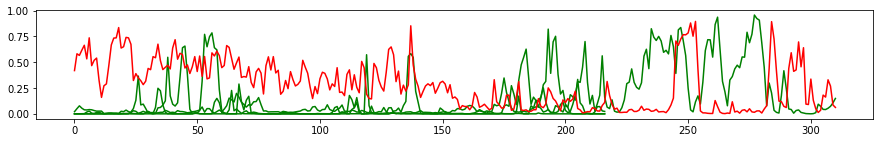

In [289]:
plot_df(results1[7][1], ab_test.df)

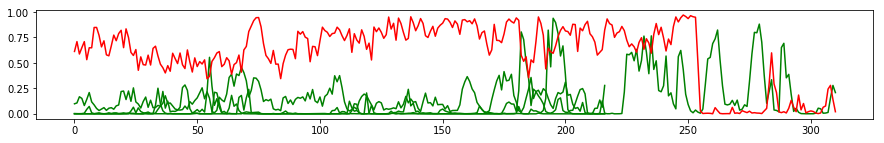

In [300]:
save('s2_linear_wp_10_10', results1[7][0])
plot_df(results1[7][0], ab_test.df)

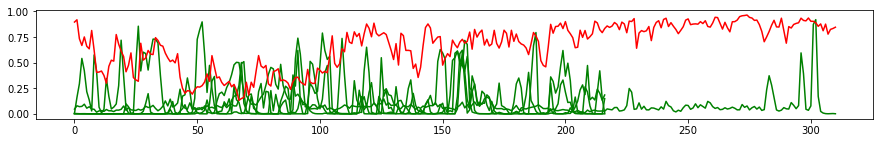

In [286]:
# stalk singers
plot_df(results1[7][0], ab.df.query('who == "p"'))

0.04304882977157831


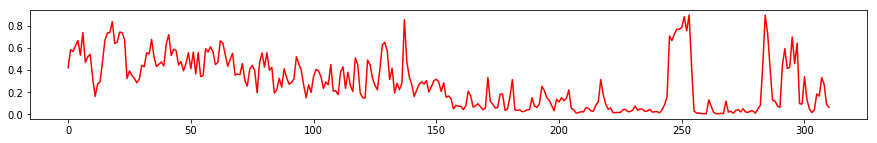

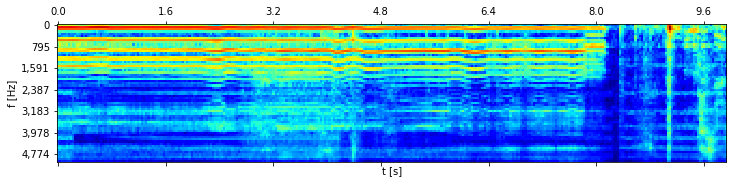

In [288]:
# a bad one (eval set)
plot_df(results1[7][1], ab.df.query('who == "g" and what == "otief"'))
util.plot_logmel(ab.df.loc['otief_g_s2', 'logmel'])
print(ab.df.loc['otief_g_s2', 'rand_stable'])
# ab.play('otief_g_s2', stop=3)

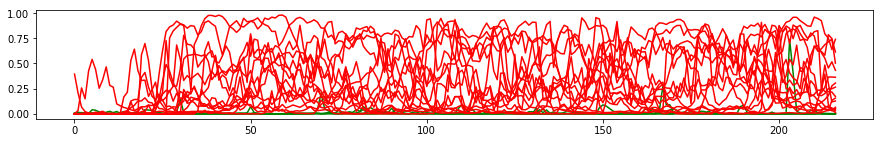

In [216]:
plot_df(results1[7][1], ab.df, dict(classes='m_o1'))

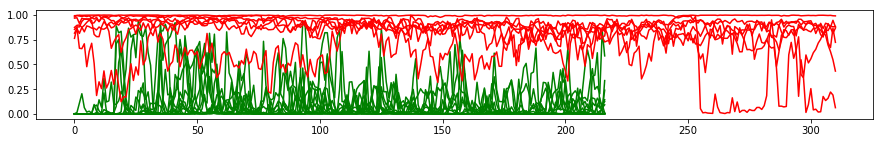

In [220]:
plot_df(results1[7][1], ab.df, dict(classes='t_o2'))

In [215]:
a,b = split_df(ab.df, 'm_o1')
b.index

Index(['o_a_1', 'o_a_2', 'o_a_3', 'o_a_4', 'o_a_5', 'o_g_1', 'o_g_2', 'o_g_3',
       'o_g_4', 'o_g_5', 'o_p_1', 'o_p_2', 'o_p_3', 'o_p_4', 'o_p_5'],
      dtype='object', name='name')

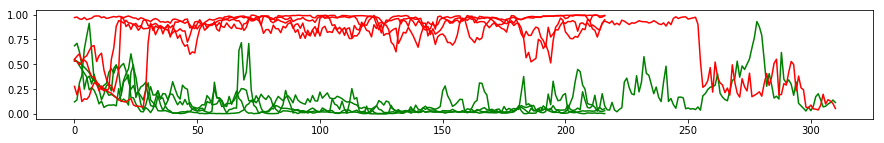

In [77]:
plot_df(results1[8][0], ab_test.df)

In [221]:
# other architectures not worth it
conf = conf_base.spawn(experiment='archs2', verbose=0, epochs=2,
                       preprocessor='wp_50_20', classes='tm_o2')
results2 = experiments([
    conf.spawn(units=units, epochs=epochs)
    for units in ((), (5,), (10,), (10, 5))
    for epochs in (2, 5, 10)
], ('units', 'epochs'))

#000                 ()-2: 0.9137, 0.8191, 0.8160,  -> 0.8496 ± 0.0453  [2.2s ± 0.3s]
#001                 ()-5: 0.8659, 0.8337, 0.8857,  -> 0.8617 ± 0.0214  [6.4s ± 2.4s]
#002                ()-10: 0.8742, 0.9127, 0.8742,  -> 0.8870 ± 0.0181  [6.6s ± 0.5s]
#003               (5,)-2: 0.8971, 0.8451, 0.9148,  -> 0.8857 ± 0.0296  [2.0s ± 0.1s]
#004               (5,)-5: 0.8004, 0.8586, 0.9262,  -> 0.8617 ± 0.0514  [3.9s ± 0.1s]
#005              (5,)-10: 0.8576, 0.9356, 0.7162,  -> 0.8365 ± 0.0908  [7.0s ± 0.1s]
#006              (10,)-2: 0.9387, 0.8784, 0.8690,  -> 0.8954 ± 0.0309  [2.0s ± 0.1s]
#007              (10,)-5: 0.8482, 0.7131, 0.9023,  -> 0.8212 ± 0.0796  [3.9s ± 0.1s]
#008             (10,)-10: 0.7474, 0.8420, 0.8243,  -> 0.8046 ± 0.0411  [7.2s ± 0.1s]
#009            (10, 5)-2: 0.6830, 0.7443, 0.9096,  -> 0.7789 ± 0.0957  [2.7s ± 0.3s]
#010            (10, 5)-5: 0.7620, 0.9376, 0.6902,  -> 0.7966 ± 0.1039  [4.4s ± 0.1s]
#011           (10, 5)-10: 0.7443, 0.8337, 0.8805,  ->

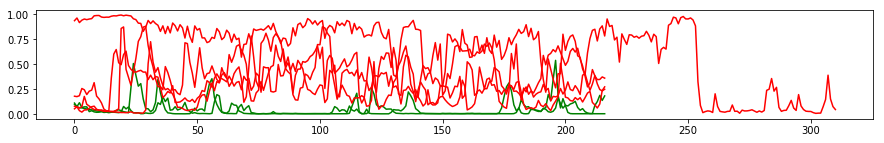

In [241]:
plot_df(results2[3][2], ab_test.df, dict(classes='t_o'))

In [292]:
# longer training : signal a lot clearer for training set, but not so for
# evaluation set
conf = conf_base.spawn(experiment='epochs2', verbose=0,
                       preprocessor='wp_10_10', classes='tm_o2')
results3 = experiments([
    conf.spawn(epochs=epochs)
    for epochs in (2, 5, 10, 20)
], ('units', 'epochs'))

#000                 ()-2: 0.6975, 0.7963, 0.7630,  -> 0.7523 ± 0.0410  [2.0s ± 0.2s]
#001                 ()-5: 0.8389, 0.8264, 0.7734,  -> 0.8129 ± 0.0284  [3.6s ± 0.0s]
#002                ()-10: 0.7277, 0.8358, 0.7838,  -> 0.7824 ± 0.0441  [6.7s ± 0.2s]
#003                ()-20: 0.7640, 0.7620, 0.8202,  -> 0.7821 ± 0.0270  [12.4s ± 0.3s]


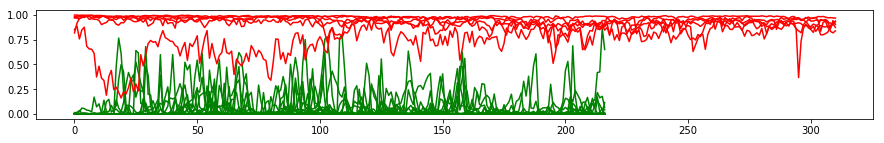

In [298]:
plot_df(results3[1][0], ab_train.df)

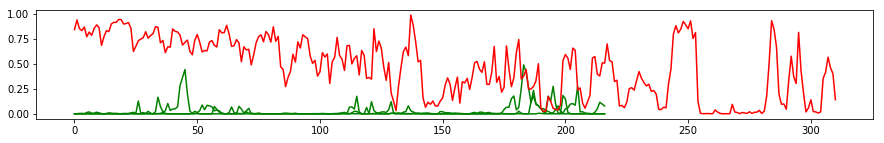

In [299]:
plot_df(results3[1][0], ab_test.df)

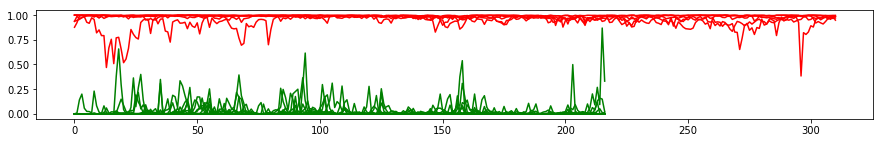

In [293]:
plot_df(results3[3][2], ab_train.df)

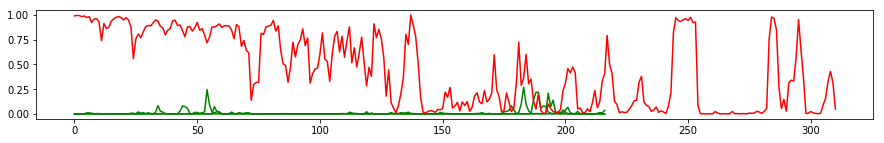

In [294]:
plot_df(results3[3][2], ab_test.df)

### session 1

a, p, g

In [121]:
conf = conf_base.spawn(experiment='preprocessors', verbose=0, epochs=2)
results = experiments([
    conf.spawn(classes=classes, preprocessor=preprocessor)
    for classes in ('t_o', 'tm_o')
    for preprocessor in ('none', 'wp_20_20', 'wp_10_10', 'wp_50_20', 'wp_20_50')
], ('classes', 'preprocessor',))

#000             t_o-none: 0.8636, 0.8442, 0.8922,  -> 0.8667 ± 0.0197  [2.0s ± 0.1s]
#001         t_o-wp_20_20: 0.8415, 0.8378, 0.9143,  -> 0.8645 ± 0.0352  [1.9s ± 0.0s]
#002         t_o-wp_10_10: 0.9032, 0.9207, 0.8221,  -> 0.8820 ± 0.0430  [1.9s ± 0.0s]
#003         t_o-wp_50_20: 0.8995, 0.8802, 0.9124,  -> 0.8974 ± 0.0133  [2.1s ± 0.1s]
#004         t_o-wp_20_50: 0.9152, 0.9060, 0.9124,  -> 0.9112 ± 0.0039  [2.1s ± 0.1s]
#005            tm_o-none: 0.8810, 0.8856, 0.8579,  -> 0.8748 ± 0.0121  [3.5s ± 1.8s]
#006        tm_o-wp_20_20: 0.9163, 0.9217, 0.8456,  -> 0.8945 ± 0.0346  [2.2s ± 0.1s]
#007        tm_o-wp_10_10: 0.8763, 0.8602, 0.8825,  -> 0.8730 ± 0.0094  [2.2s ± 0.0s]
#008        tm_o-wp_50_20: 0.9009, 0.9140, 0.9178,  -> 0.9109 ± 0.0072  [2.3s ± 0.0s]
#009        tm_o-wp_20_50: 0.9078, 0.9293, 0.9416,  -> 0.9263 ± 0.0140  [2.2s ± 0.1s]


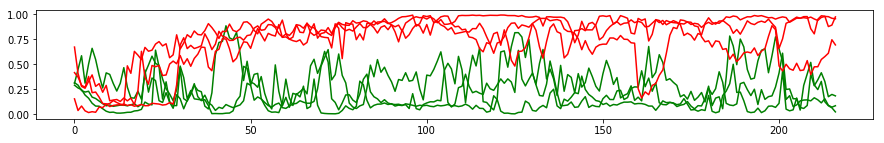

In [179]:
plot_df(results[7][2], ab_test.df)
save('tmo_wp_10_10_linear', results[7][2])

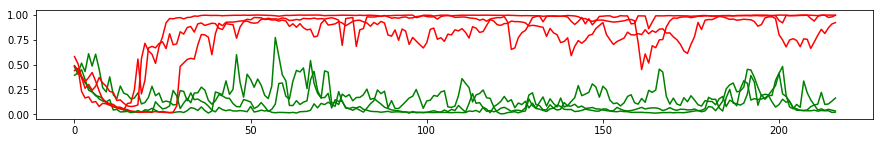

In [180]:
plot_df(results[9][2], ab_test.df)
save('tmo_wp_20_50_linear', results[9][2])

In [116]:
# > 10 epochs : overfit
conf = conf_base.spawn(experiment='longer', verbose=0, classes='tm_o', preprocessor='wp_20_20')
results = experiments([
    conf.spawn(epochs=epochs)
    for epochs in (10, 20, 50)
], ('epochs',))

#000                   10: 0.9055, 0.9040, 0.9263,  -> 0.9119 ± 0.0102  [8.4s ± 1.4s]
#001                   20: 0.8863, 0.8955, 0.9032,  -> 0.8950 ± 0.0069  [15.0s ± 1.1s]
#002                   50: 0.8817, 0.8564, 0.8856,  -> 0.8746 ± 0.0129  [36.4s ± 2.2s]


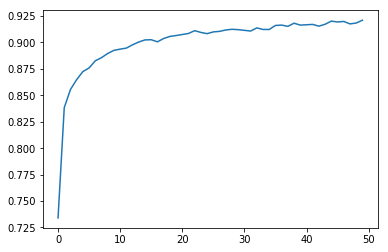

In [117]:
plt.plot(results[2][2].history['accuracy'])

In [119]:
# 2 epochs best ?
conf = conf_base.spawn(experiment='shorter', verbose=0, classes='tm_o', preprocessor='wp_20_20')
results = experiments([
    conf.spawn(epochs=epochs)
    for epochs in (1, 2, 5, 10, 15)
], ('epochs',))

#000                    1: 0.9017, 0.8986, 0.8771,  -> 0.8925 ± 0.0109  [1.5s ± 0.1s]
#001                    2: 0.9316, 0.9002, 0.9117,  -> 0.9145 ± 0.0130  [2.1s ± 0.0s]
#002                    5: 0.9224, 0.9178, 0.8909,  -> 0.9104 ± 0.0139  [4.2s ± 0.1s]
#003                   10: 0.8725, 0.9117, 0.8932,  -> 0.8925 ± 0.0160  [7.5s ± 0.3s]
#004                   15: 0.9140, 0.9063, 0.8840,  -> 0.9014 ± 0.0127  [11.1s ± 0.2s]


# use

## from signals

In [313]:
S.KerasDetector('tmo_wp_20_50_linear')

KerasDetector(model=tmo_wp_20_50_linear)

In [343]:
signals = dict(
    tf1=S.KerasDetector('tmo_wp_20_50_linear'),
    tf2=S.KerasDetector('s2_linear_wp_10_10'),
)
name = 'otief_g_s2'
values = util.get_signals(ab.wav(name), signals)
values.keys()

dict_keys(['features', 't', 'signalin', 'state', 'tf2', 'tf1'])

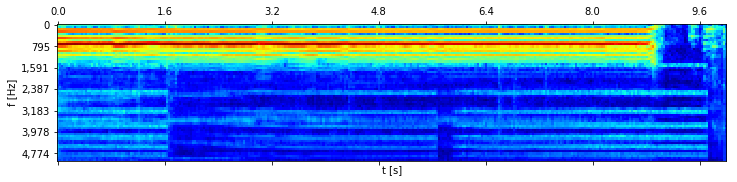

In [344]:
logmel = np.array([feats.logmel for feats in values['features']])
util.plot_logmel(logmel)

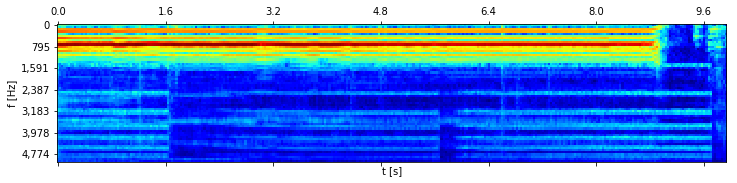

In [345]:
util.plot_logmel(ab.df.loc[name, 'logmel'])

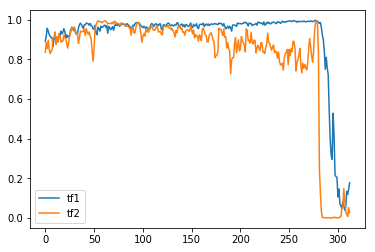

In [346]:
util.plot_logmel
plt.plot(values['tf1'], label='tf1')
plt.plot(values['tf2'], label='tf2')
plt.legend();

## from logmel

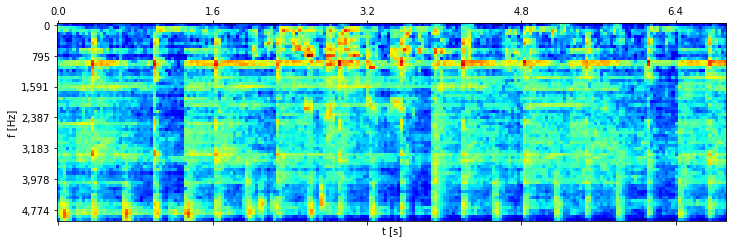

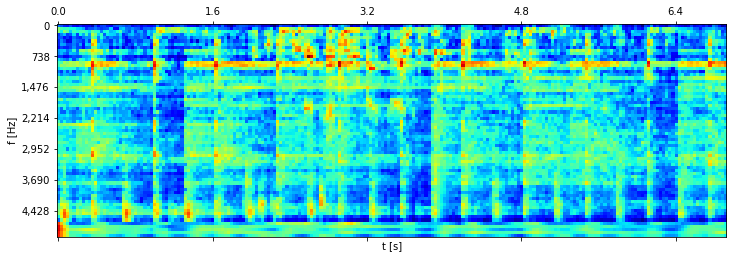

In [157]:
logmel = ab_train.df.logmel.iloc[0]
wp = S.WithPrevious(n=5, d=5)
util.plot_logmel(logmel, vmin=logmel.min(), vmax=logmel.max())
util.plot_logmel(np.concatenate([[wp(_)] for _ in logmel]), vmin=logmel.min(), vmax=logmel.max())

In [158]:
# model = tf.keras.models.load_model(os.path.join(model_dir, 'to_none_linear.h5'))
# preprocessor = lambda x: x
# model = tf.keras.models.load_model(os.path.join(model_dir, 'to_wp_5_5_linear.h5'))
# preprocessor = S.WithPrevious(n=5, d=5)
# model = tf.keras.models.load_model(os.path.join(model_dir, 'tmo_wp_10_10_linear.h5'))
# preprocessor = S.WithPrevious(n=10, d=10)
model = tf.keras.models.load_model(os.path.join(model_dir, 'tmo_wp_20_50_linear.h5'))
preprocessor = S.WithPrevious(n=20, d=50)

detector = S.KerasDetector(model, preprocessor)

In [272]:
ab_test.df.index

Index(['m_g_1', 'o_a_2', 'o_g_1', 'o_g_3', 't_a_2', 't_g_2', 'w_a_1'], dtype='object', name='name')

In [159]:
def logmel_pred(detectors, logmel):
    plt.figure(figsize=(15, 5))
    util.plot_logmel(logmel, ax=plt.subplot(211), aspect='auto')
    try: iter(detectors)
    except TypeError: detectors = (detectors,)
    ax = plt.subplot(212)
    for detector in detectors:
        ax.plot([detector(lm) for lm in logmel])

In [160]:
mf = S.MedianFilter(detector, n=4)
mf2 = S.MedianFilter(detector, n=10)
mf3 = S.MedianFilter(detector, n=10, threshold=0.5)
detectors = (detector, mf, mf2, mf3)

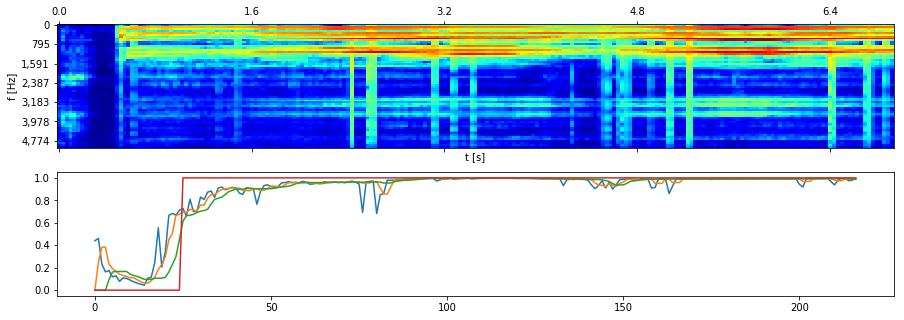

In [161]:
logmel_pred(detectors, ab_test.df.loc['o_a_2', 'logmel'])

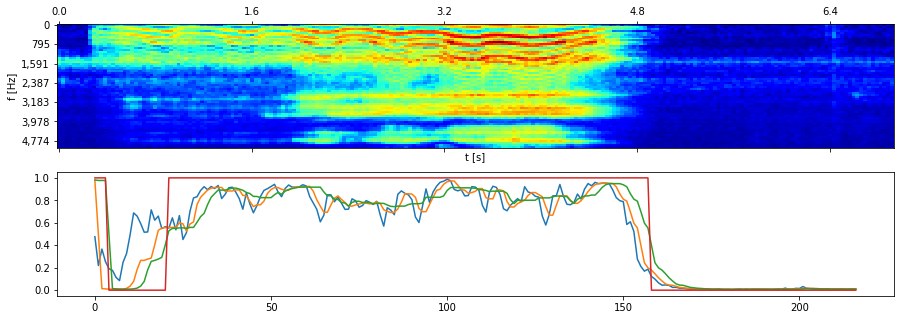

In [162]:
logmel_pred(detectors, ab_test.df.loc['w_a_1', 'logmel'])

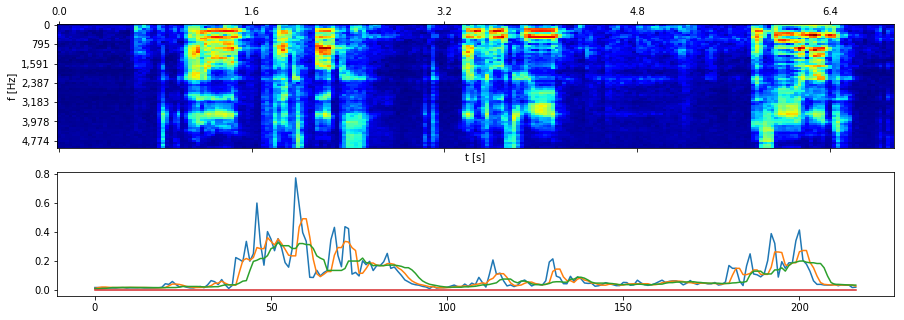

In [163]:
logmel_pred(detectors, ab_test.df.loc['t_g_2', 'logmel'])

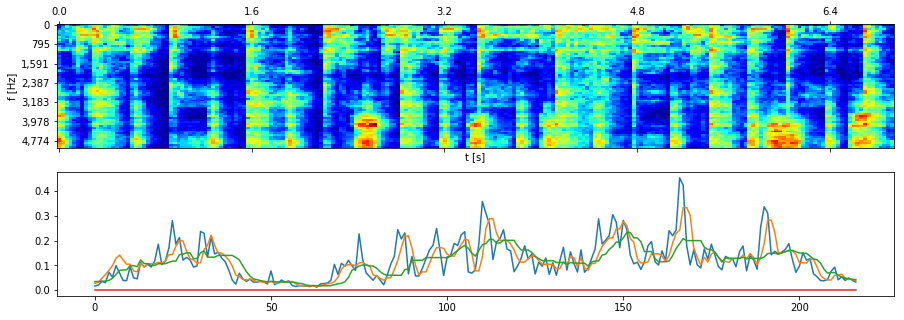

In [164]:
logmel_pred(detectors, ab_test.df.loc['m_g_1', 'logmel'])

# debug

## difference with monitor

nets with high accuracy on eval set have random behavior when inspecting with
recorder2.py/monitor.py

(from old version; behavior now fixed)

(3.7864342122603714, 11.126097687572154)

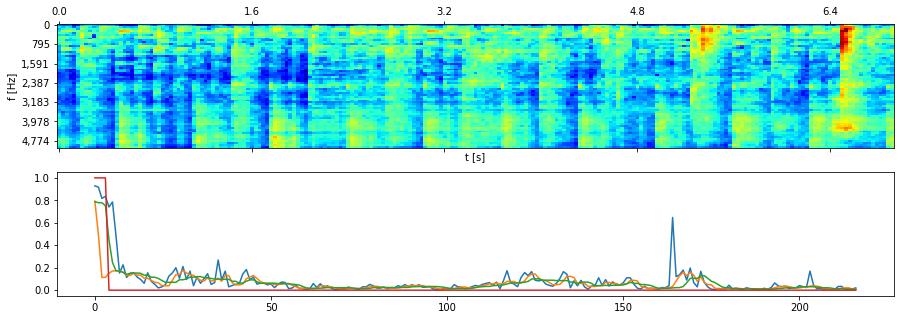

In [295]:
abase_logmel = ab_train.df.loc['m_g_3', 'logmel']
logmel_pred(detectors, abase_logmel)
abase_logmel.min(), abase_logmel.max()

(-4.52465800512057, 0.73370267448466)

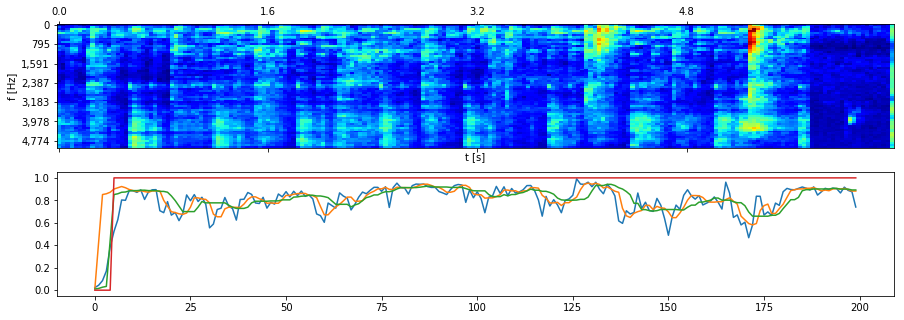

In [317]:
with open('../py/logmel001.pickle', 'rb') as f:
    monitor_logmel = pickle.load(f)
logmel_pred(detectors, monitor_logmel)
monitor_logmel.min(), monitor_logmel.max()

In [296]:
audio_interface = audio.AudioInterface(input_channels=1)
wav = audio_interface.record(secs=2)

* recording
* done recording


(4.048216484207795, 12.40923287137952)

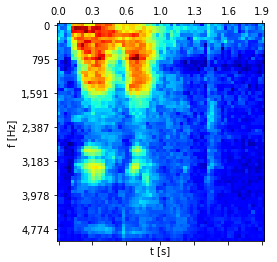

In [298]:
logmel = features.log_mel_spectrogram(wav)
util.plot_logmel(logmel)
logmel.min(), logmel.max()

In [310]:
scipy.io.wavfile.write('../recordings/test.wav', settings.rate, wav)
ab2 = abase.ABase(load_wav=True)

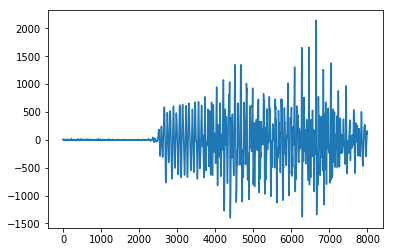

In [312]:
plt.plot(wav[:8000])

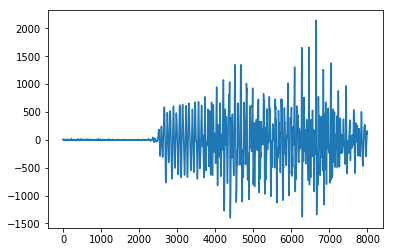

In [314]:
plt.plot(ab2.df.loc['test', 'wav'][:8000])

In [315]:
ab2.transform('logmel', lambda row: features.log_mel_spectrogram(row['wav']))

Updated 36/36 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/logmel.pickle : 3.74M (0.0s)


(4.048216484207795, 12.40923287137952)

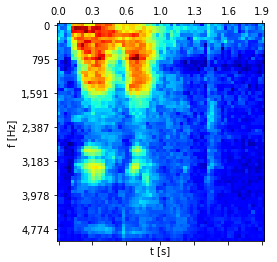

In [316]:
logmel_ = ab2.df.loc['test', 'logmel']
util.plot_logmel(logmel_)
logmel_.min(), logmel_.max()

In [318]:
# => culprit is scaling in util.int16_to_float() that is called from
#    recorder2.py but not in abase ...
wav_f = util.int16_to_float(wav)
logmel_f = features.log_mel_spectrogram(wav_f)
logmel_f.min(), logmel_f.max()

(-4.444054822334877, 2.0133614050072306)